Loaded 112 store-period demand estimates.
Loaded 60 optimal routes.

Running 1,000 combined demand + traffic simulations...
Simulation complete.

COMBINED DEMAND + TRAFFIC SIMULATION
                               Metric         Value
                          Simulations   1000.000000
                    Mean weekday cost  64977.099396
                   Mean Saturday cost  27645.244700
                     Mean weekly cost 352530.741680
           5th percentile weekly cost 272959.254083
          95th percentile weekly cost 453648.116415
                  Mean weekday demand    447.256000
                 Mean Saturday demand    275.497000
                   Mean weekly demand    722.753000
                   Mean weekday hours    162.135452
                  Mean Saturday hours    103.757976
        Probability weekday wet lease      0.998000
       Probability Saturday wet lease      0.001000
  Mean weekday demand-overflow trucks      3.603000
 Mean Saturday demand-overflow trucks

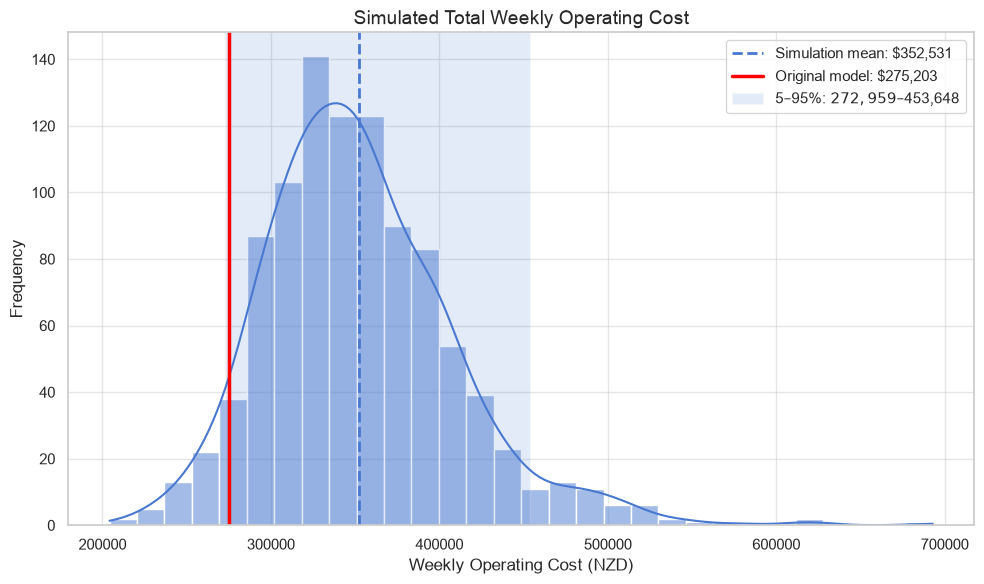

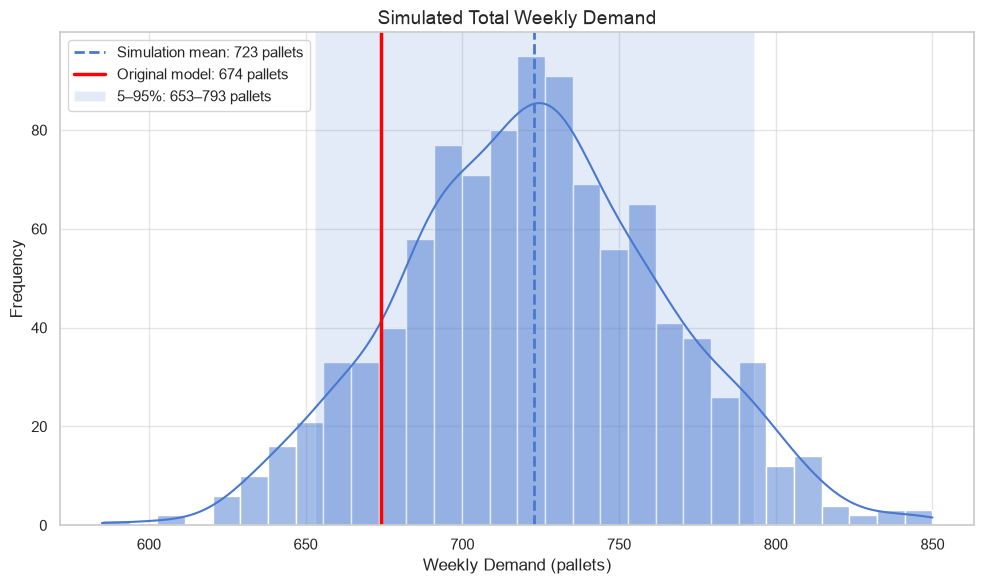

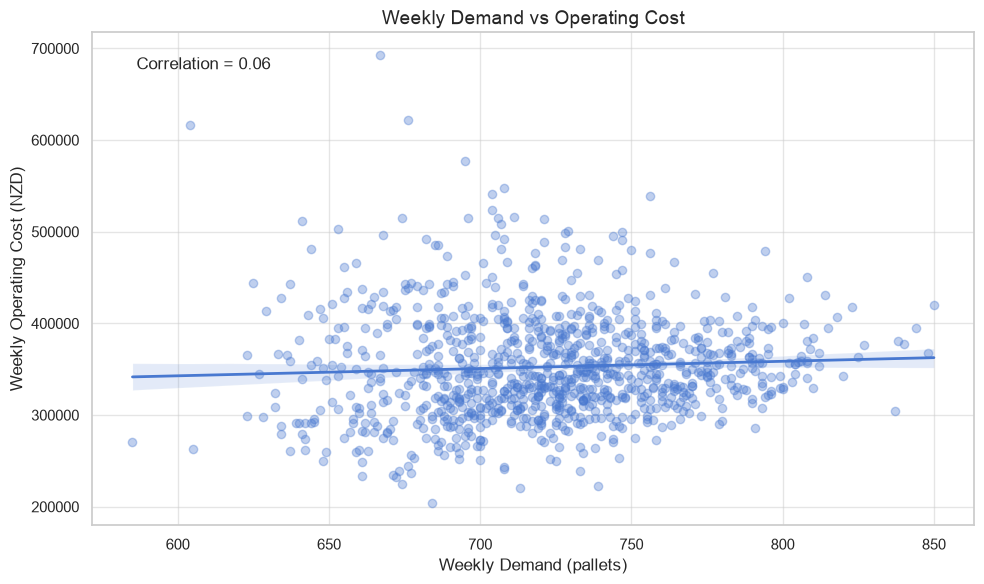

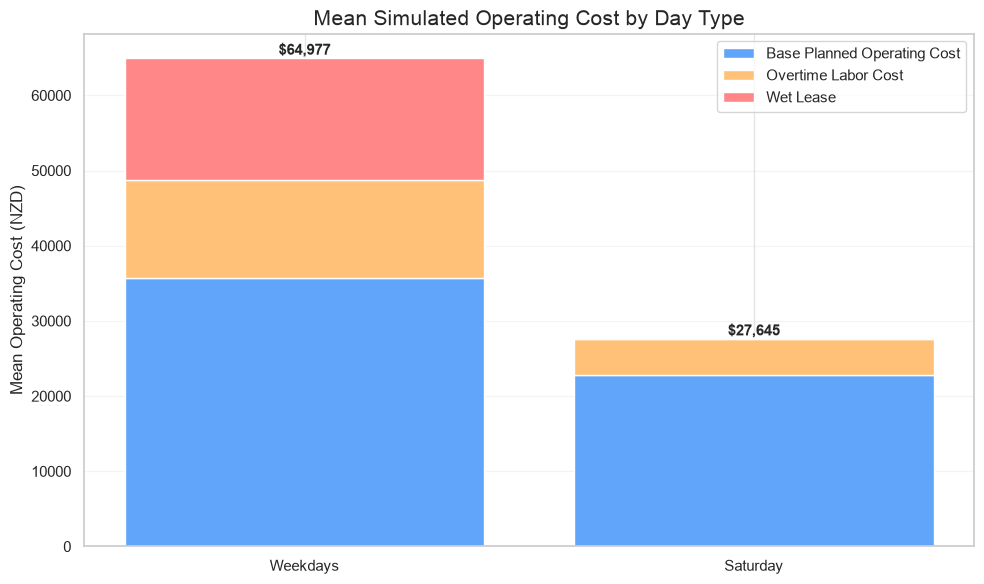

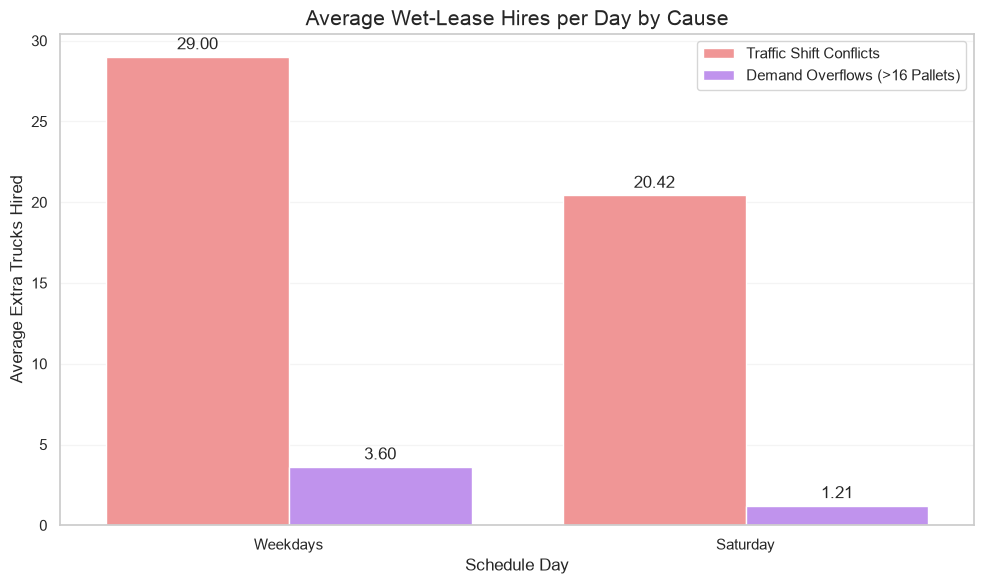

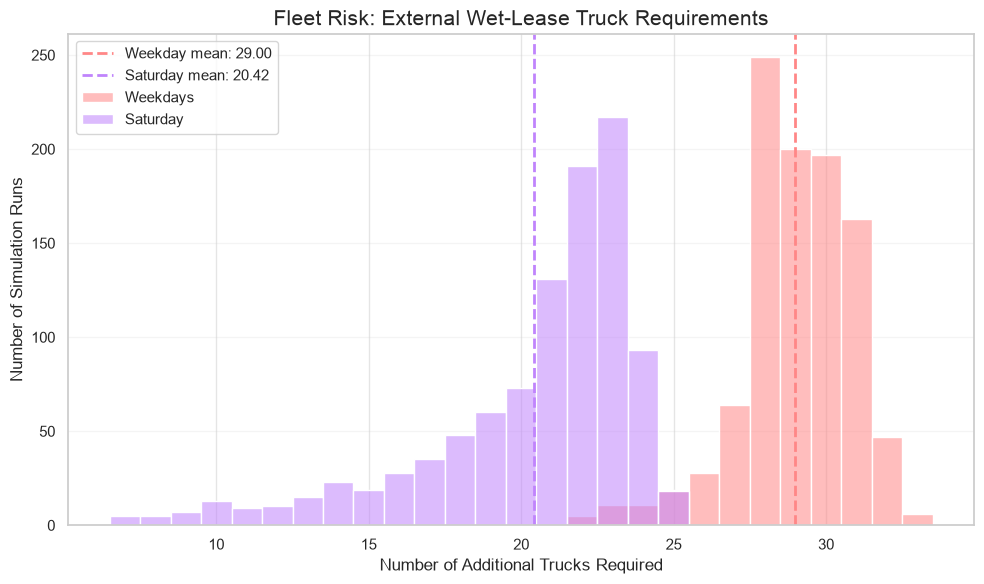


FLEET RISK — EXTERNAL TRUCK REQUIREMENTS

Weekdays:
  Average extra trucks required: 29.00
  Maximum extra trucks required: 33
  Probability extra truck required: 100.0%

Saturday:
  Average extra trucks required: 20.42
  Maximum extra trucks required: 25
  Probability extra truck required: 100.0%

Simulation results saved.


In [131]:
from __future__ import annotations

import math
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. USER SETTINGS
# ============================================================

OPTIMAL_ROUTE_FILE = Path(
    "project_data/optimal_routes.csv"
)

DEMAND_FILE = Path(
    "project_data/demand_estimate.csv"
)

N_SIMULATIONS = 1000
RANDOM_SEED = 263


# ============================================================
# DEMAND VARIATION
# ============================================================

DAY_TO_DAY_DEMAND_SIGMA = 0.08
STORE_TO_STORE_DEMAND_SIGMA = 0.05


# ============================================================
# TRAFFIC VARIATION
# ============================================================

DAY_TO_DAY_TRAFFIC_SIGMA = 0.30
ROUTE_TO_ROUTE_TRAFFIC_SIGMA = 0.15


# ============================================================
# OPERATIONAL PARAMETERS
# ============================================================

TRUCK_CAPACITY = 16.0

PLANNED_SHIFT_HOURS = 3.5

UNLOAD_MINUTES_PER_PALLET = 18.0

TRUCK_COST_PER_HOUR = 220.0

OVERTIME_THRESHOLD_HOURS = 4.0
OVERTIME_COST_PER_BLOCK = 310.0

WET_LEASE_COST_PER_2H_BLOCK = 1400.0

# 20 owned trucks × 2 shifts × 3.5 hours
NORMAL_TRUCK_HOURS = 20 * 2 * 3.5


# ============================================================
# ORIGINAL DETERMINISTIC MODEL VALUES
# ============================================================

ORIGINAL_WEEKDAY_COST = 50_261.82
ORIGINAL_SATURDAY_COST = 23_894.01
ORIGINAL_WEEKLY_COST = 275_203.11

ORIGINAL_WEEKLY_DEMAND = 674


# ============================================================
# PLOT COLOURS
# ============================================================

COLOURS = {
    "base": "#60A5FA",
    "overtime": "#FFC078",
    "traffic": "#FF8787",
    "demand": "#C084FC"
}


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def parse_route(route_text: str) -> List[str]:
    """Split route into individual stops."""

    return [
        part.strip()
        for part in str(route_text).split("->")
        if part.strip()
    ]


def ceil_hours_over_threshold(
    total_hours: float,
    threshold: float
) -> int:
    """Calculate overtime blocks above the threshold."""

    extra = total_hours - threshold

    if extra <= 0:
        return 0

    return int(
        math.ceil(extra - 1e-12)
    )


# ============================================================
# 3. LOAD DEMAND DATA
# ============================================================

if not DEMAND_FILE.exists():

    raise FileNotFoundError(
        f"Missing demand file: "
        f"{DEMAND_FILE.resolve()}"
    )


demand_df = pd.read_csv(
    DEMAND_FILE
)


required_demand_columns = [
    "Supermarket",
    "Period",
    "Demand"
]


missing = [
    col
    for col in required_demand_columns
    if col not in demand_df.columns
]


if missing:

    raise ValueError(
        f"Missing demand columns: {missing}"
    )


demand_df["Demand"] = pd.to_numeric(
    demand_df["Demand"],
    errors="coerce"
)


if demand_df["Demand"].isna().any():

    raise ValueError(
        "Some demand values could not be converted to numbers."
    )


# ============================================================
# CREATE DEMAND LOOKUP
# ============================================================

demand_lookup = {
    (
        row["Supermarket"],
        row["Period"]
    ): float(row["Demand"])

    for _, row in demand_df.iterrows()
}


print(
    f"Loaded {len(demand_df):,} "
    "store-period demand estimates."
)


# ============================================================
# 4. LOAD OPTIMAL ROUTES
# ============================================================

if not OPTIMAL_ROUTE_FILE.exists():

    raise FileNotFoundError(
        f"Missing optimal route file: "
        f"{OPTIMAL_ROUTE_FILE.resolve()}"
    )


routes_df = pd.read_csv(
    OPTIMAL_ROUTE_FILE
)


required_route_columns = [
    "Day",
    "Route",
    "Duration_hours"
]


missing = [
    col
    for col in required_route_columns
    if col not in routes_df.columns
]


if missing:

    raise ValueError(
        f"Missing route columns: {missing}"
    )


print(
    f"Loaded {len(routes_df):,} optimal routes."
)


# ============================================================
# 5. PREPARE ROUTES
# ============================================================

routes = []


for _, row in routes_df.iterrows():

    stops = parse_route(
        row["Route"]
    )

    stores = [
        stop
        for stop in stops
        if stop.lower() != "warehouse"
    ]

    routes.append(
        {
            "Day": row["Day"],
            "Route": row["Route"],
            "Duration_hours":
                float(row["Duration_hours"]),
            "Stores": stores
        }
    )


# ============================================================
# 6. COMBINED DEMAND + TRAFFIC SIMULATION
# ============================================================

def simulate_combined(
    routes: list,
    n_simulations: int,
    rng: np.random.Generator
) -> pd.DataFrame:

    simulation_results = []


    for simulation in range(
        1,
        n_simulations + 1
    ):

        # ====================================================
        # DAILY DEMAND FACTORS
        # ====================================================

        weekday_demand_factor = rng.lognormal(
            mean=(
                -0.5
                * DAY_TO_DAY_DEMAND_SIGMA**2
            ),
            sigma=DAY_TO_DAY_DEMAND_SIGMA
        )


        saturday_demand_factor = rng.lognormal(
            mean=(
                -0.5
                * DAY_TO_DAY_DEMAND_SIGMA**2
            ),
            sigma=DAY_TO_DAY_DEMAND_SIGMA
        )


        # ====================================================
        # DAILY TRAFFIC FACTORS
        # ====================================================

        weekday_traffic_factor = rng.lognormal(
            mean=(
                -0.5
                * DAY_TO_DAY_TRAFFIC_SIGMA**2
            ),
            sigma=DAY_TO_DAY_TRAFFIC_SIGMA
        )


        saturday_traffic_factor = rng.lognormal(
            mean=(
                -0.5
                * DAY_TO_DAY_TRAFFIC_SIGMA**2
            ),
            sigma=DAY_TO_DAY_TRAFFIC_SIGMA
        )


        # ====================================================
        # DAY-LEVEL VARIABLES
        # ====================================================

        weekday_cost = 0.0
        saturday_cost = 0.0

        weekday_demand = 0.0
        saturday_demand = 0.0

        weekday_hours = 0.0
        saturday_hours = 0.0

        weekday_overtime_blocks = 0
        saturday_overtime_blocks = 0

        weekday_routes_over_35 = 0
        saturday_routes_over_35 = 0

        weekday_routes_over_4 = 0
        saturday_routes_over_4 = 0


        # ====================================================
        # NEW FLEET-RISK VARIABLES
        # ====================================================

        weekday_demand_overflow_trucks = 0
        saturday_demand_overflow_trucks = 0

        weekday_traffic_conflict_trucks = 0
        saturday_traffic_conflict_trucks = 0


        # ====================================================
        # SIMULATE EACH OPTIMAL ROUTE
        # ====================================================

        for route in routes:

            day = route["Day"]

            route_stores = route["Stores"]

            original_duration = (
                route["Duration_hours"]
            )


            # =================================================
            # DAY TYPE
            # =================================================

            if day == "Weekdays":

                period = "Weekdays"

                day_demand_factor = (
                    weekday_demand_factor
                )

                day_traffic_factor = (
                    weekday_traffic_factor
                )

            elif day == "Saturday":

                period = "Saturday"

                day_demand_factor = (
                    saturday_demand_factor
                )

                day_traffic_factor = (
                    saturday_traffic_factor
                )

            else:

                raise ValueError(
                    f"Unexpected day type: {day}"
                )


            # =================================================
            # SIMULATE DEMAND
            # =================================================

            route_demand = 0.0


            for store in route_stores:

                key = (
                    store,
                    period
                )


                if key not in demand_lookup:

                    raise ValueError(
                        f"No demand estimate found for "
                        f"{store} ({period})"
                    )


                baseline_demand = (
                    demand_lookup[key]
                )


                store_factor = rng.lognormal(
                    mean=(
                        -0.5
                        * STORE_TO_STORE_DEMAND_SIGMA**2
                    ),
                    sigma=STORE_TO_STORE_DEMAND_SIGMA
                )


                simulated_demand = (
                    baseline_demand
                    * day_demand_factor
                    * store_factor
                )


                simulated_demand = np.ceil(
                    simulated_demand
                )


                route_demand += (
                    simulated_demand
                )


            # =================================================
            # DEMAND CAPACITY RISK
            # =================================================

            # This DOES NOT change the route or cost model.
            # It simply records how many additional trucks
            # would be required if this route exceeds 16 pallets.

            if route_demand > TRUCK_CAPACITY:

                demand_overflow_trucks = int(
                    math.ceil(
                        route_demand
                        / TRUCK_CAPACITY
                    )
                ) - 1

            else:

                demand_overflow_trucks = 0


            # =================================================
            # UNLOADING TIME
            # =================================================

            unload_hours = (
                route_demand
                * UNLOAD_MINUTES_PER_PALLET
                / 60.0
            )


            # =================================================
            # BASE DRIVING TIME
            # =================================================

            base_drive_hours = max(
                0.0,
                original_duration
                - unload_hours
            )


            # =================================================
            # ROUTE TRAFFIC
            # =================================================

            route_traffic_factor = rng.lognormal(
                mean=(
                    -0.5
                    * ROUTE_TO_ROUTE_TRAFFIC_SIGMA**2
                ),
                sigma=ROUTE_TO_ROUTE_TRAFFIC_SIGMA
            )


            traffic_multiplier = (
                day_traffic_factor
                * route_traffic_factor
            )


            # =================================================
            # FINAL ROUTE DURATION
            # =================================================

            actual_hours = (
                base_drive_hours
                * traffic_multiplier
                + unload_hours
            )


            # =================================================
            # TRAFFIC SHIFT-CONFLICT RISK
            # =================================================

            # This records routes that exceed the planned
            # 3.5-hour shift.

            if actual_hours > PLANNED_SHIFT_HOURS:

                traffic_conflict_trucks = 1

            else:

                traffic_conflict_trucks = 0


            # =================================================
            # NORMAL TRUCK COST
            # =================================================

            normal_cost = (
                actual_hours
                * TRUCK_COST_PER_HOUR
            )


            # =================================================
            # OVERTIME
            # =================================================

            overtime_blocks = (
                ceil_hours_over_threshold(
                    actual_hours,
                    OVERTIME_THRESHOLD_HOURS
                )
            )


            overtime_cost = (
                overtime_blocks
                * OVERTIME_COST_PER_BLOCK
            )


            # =================================================
            # STORE DAY RESULTS
            # =================================================

            if period == "Weekdays":

                weekday_demand += (
                    route_demand
                )

                weekday_hours += (
                    actual_hours
                )

                weekday_overtime_blocks += (
                    overtime_blocks
                )

                weekday_routes_over_35 += (
                    actual_hours > 3.5
                )

                weekday_routes_over_4 += (
                    actual_hours > 4.0
                )

                weekday_cost += (
                    normal_cost
                    + overtime_cost
                )

                weekday_demand_overflow_trucks += (
                    demand_overflow_trucks
                )

                weekday_traffic_conflict_trucks += (
                    traffic_conflict_trucks
                )


            else:

                saturday_demand += (
                    route_demand
                )

                saturday_hours += (
                    actual_hours
                )

                saturday_overtime_blocks += (
                    overtime_blocks
                )

                saturday_routes_over_35 += (
                    actual_hours > 3.5
                )

                saturday_routes_over_4 += (
                    actual_hours > 4.0
                )

                saturday_cost += (
                    normal_cost
                    + overtime_cost
                )

                saturday_demand_overflow_trucks += (
                    demand_overflow_trucks
                )

                saturday_traffic_conflict_trucks += (
                    traffic_conflict_trucks
                )


        # ====================================================
        # WET LEASING
        # ====================================================

        # IMPORTANT:
        # This is unchanged from the previous simulation.
        # Wet leasing is still based on total hours exceeding
        # the available 140 owned-truck hours.

        weekday_extra_hours = max(
            0.0,
            weekday_hours
            - NORMAL_TRUCK_HOURS
        )


        weekday_wet_lease_blocks = (
            math.ceil(
                weekday_extra_hours / 2.0
                - 1e-12
            )
            if weekday_extra_hours > 0
            else 0
        )


        weekday_wet_lease_cost = (
            weekday_wet_lease_blocks
            * WET_LEASE_COST_PER_2H_BLOCK
        )


        weekday_cost += (
            weekday_wet_lease_cost
        )


        saturday_extra_hours = max(
            0.0,
            saturday_hours
            - NORMAL_TRUCK_HOURS
        )


        saturday_wet_lease_blocks = (
            math.ceil(
                saturday_extra_hours / 2.0
                - 1e-12
            )
            if saturday_extra_hours > 0
            else 0
        )


        saturday_wet_lease_cost = (
            saturday_wet_lease_blocks
            * WET_LEASE_COST_PER_2H_BLOCK
        )


        saturday_cost += (
            saturday_wet_lease_cost
        )


        # ====================================================
        # WEEKLY VALUES
        # ====================================================

        # IMPORTANT:
        # No ×5 is used here.

        weekly_cost = (
                (weekday_cost * 5)
            + saturday_cost
        )


        weekly_demand = (
            weekday_demand
            + saturday_demand
        )


        weekly_hours = (
            weekday_hours
            + saturday_hours
        )


        # ====================================================
        # TOTAL EXTRA TRUCK RISK
        # ====================================================

        weekday_extra_trucks = max(
            weekday_demand_overflow_trucks,
            weekday_traffic_conflict_trucks
        )


        saturday_extra_trucks = max(
            saturday_demand_overflow_trucks,
            saturday_traffic_conflict_trucks
        )


        # ====================================================
        # SAVE RESULTS
        # ====================================================

        simulation_results.append(
            {

                "Simulation":
                    simulation,

                # --------------------------------------------
                # Costs
                # --------------------------------------------

                "Weekday_Cost":
                    weekday_cost,

                "Saturday_Cost":
                    saturday_cost,

                "Weekly_Cost":
                    weekly_cost,


                # --------------------------------------------
                # Demand
                # --------------------------------------------

                "Weekday_Demand":
                    weekday_demand,

                "Saturday_Demand":
                    saturday_demand,

                "Weekly_Demand":
                    weekly_demand,


                # --------------------------------------------
                # Hours
                # --------------------------------------------

                "Weekday_Hours":
                    weekday_hours,

                "Saturday_Hours":
                    saturday_hours,

                "Weekly_Hours":
                    weekly_hours,


                # --------------------------------------------
                # Overtime
                # --------------------------------------------

                "Weekday_Overtime_Blocks":
                    weekday_overtime_blocks,

                "Saturday_Overtime_Blocks":
                    saturday_overtime_blocks,


                # --------------------------------------------
                # Existing wet lease results
                # --------------------------------------------

                "Weekday_Wet_Lease_Blocks":
                    weekday_wet_lease_blocks,

                "Saturday_Wet_Lease_Blocks":
                    saturday_wet_lease_blocks,


                # --------------------------------------------
                # Route duration
                # --------------------------------------------

                "Weekday_Routes_Over_3_5h":
                    weekday_routes_over_35,

                "Saturday_Routes_Over_3_5h":
                    saturday_routes_over_35,

                "Weekday_Routes_Over_4h":
                    weekday_routes_over_4,

                "Saturday_Routes_Over_4h":
                    saturday_routes_over_4,


                # --------------------------------------------
                # NEW: FLEET RISK
                # --------------------------------------------

                "Weekday_Demand_Overflow_Trucks":
                    weekday_demand_overflow_trucks,

                "Saturday_Demand_Overflow_Trucks":
                    saturday_demand_overflow_trucks,

                "Weekday_Traffic_Conflict_Trucks":
                    weekday_traffic_conflict_trucks,

                "Saturday_Traffic_Conflict_Trucks":
                    saturday_traffic_conflict_trucks,

                "Weekday_Extra_Trucks_Required":
                    weekday_extra_trucks,

                "Saturday_Extra_Trucks_Required":
                    saturday_extra_trucks
            }
        )


    return pd.DataFrame(
        simulation_results
    )


# ============================================================
# 7. RUN SIMULATION
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)


print(
    f"\nRunning {N_SIMULATIONS:,} "
    "combined demand + traffic simulations..."
)


results = simulate_combined(
    routes=routes,
    n_simulations=N_SIMULATIONS,
    rng=rng
)


print(
    "Simulation complete."
)


# ============================================================
# 8. SUMMARY
# ============================================================

summary = pd.DataFrame(
    {
        "Metric": [

            "Simulations",

            "Mean weekday cost",
            "Mean Saturday cost",
            "Mean weekly cost",

            "5th percentile weekly cost",
            "95th percentile weekly cost",

            "Mean weekday demand",
            "Mean Saturday demand",
            "Mean weekly demand",

            "Mean weekday hours",
            "Mean Saturday hours",

            "Probability weekday wet lease",
            "Probability Saturday wet lease",

            "Mean weekday demand-overflow trucks",
            "Mean Saturday demand-overflow trucks",

            "Mean weekday traffic-conflict trucks",
            "Mean Saturday traffic-conflict trucks",

            "Mean weekday extra trucks required",
            "Mean Saturday extra trucks required"
        ],


        "Value": [

            N_SIMULATIONS,

            results["Weekday_Cost"].mean(),
            results["Saturday_Cost"].mean(),
            results["Weekly_Cost"].mean(),

            results["Weekly_Cost"].quantile(0.05),
            results["Weekly_Cost"].quantile(0.95),

            results["Weekday_Demand"].mean(),
            results["Saturday_Demand"].mean(),
            results["Weekly_Demand"].mean(),

            results["Weekday_Hours"].mean(),
            results["Saturday_Hours"].mean(),

            (
                results[
                    "Weekday_Wet_Lease_Blocks"
                ] > 0
            ).mean(),

            (
                results[
                    "Saturday_Wet_Lease_Blocks"
                ] > 0
            ).mean(),

            results[
                "Weekday_Demand_Overflow_Trucks"
            ].mean(),

            results[
                "Saturday_Demand_Overflow_Trucks"
            ].mean(),

            results[
                "Weekday_Traffic_Conflict_Trucks"
            ].mean(),

            results[
                "Saturday_Traffic_Conflict_Trucks"
            ].mean(),

            results[
                "Weekday_Extra_Trucks_Required"
            ].mean(),

            results[
                "Saturday_Extra_Trucks_Required"
            ].mean()
        ]
    }
)


print("\n" + "=" * 70)
print("COMBINED DEMAND + TRAFFIC SIMULATION")
print("=" * 70)

print(
    summary.to_string(index=False)
)


# ============================================================
# 9. EXISTING PLOTS
# ============================================================


# ------------------------------------------------------------
# WEEKLY COST
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

sns.histplot(
    results["Weekly_Cost"],
    bins=30,
    kde=True,
    ax=ax
)

mean_cost = results[
    "Weekly_Cost"
].mean()

p5_cost = results[
    "Weekly_Cost"
].quantile(0.05)

p95_cost = results[
    "Weekly_Cost"
].quantile(0.95)


ax.axvline(
    mean_cost,
    linestyle="--",
    linewidth=2,
    label=(
        f"Simulation mean: "
        f"${mean_cost:,.0f}"
    )
)


ax.axvline(
    ORIGINAL_WEEKLY_COST,
    color="red",
    linewidth=2.5,
    label=(
        f"Original model: "
        f"${ORIGINAL_WEEKLY_COST:,.0f}"
    )
)


ax.axvspan(
    p5_cost,
    p95_cost,
    alpha=0.15,
    label=(
        f"5–95%: "
        f"${p5_cost:,.0f}–"
        f"${p95_cost:,.0f}"
    )
)


ax.set_title(
    "Simulated Total Weekly Operating Cost",
    fontsize=14
)

ax.set_xlabel(
    "Weekly Operating Cost (NZD)"
)

ax.set_ylabel(
    "Frequency"
)

ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# WEEKLY DEMAND
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

sns.histplot(
    results["Weekly_Demand"],
    bins=30,
    kde=True,
    ax=ax
)

mean_demand = results[
    "Weekly_Demand"
].mean()

p5_demand = results[
    "Weekly_Demand"
].quantile(0.05)

p95_demand = results[
    "Weekly_Demand"
].quantile(0.95)


ax.axvline(
    mean_demand,
    linestyle="--",
    linewidth=2,
    label=(
        f"Simulation mean: "
        f"{mean_demand:,.0f} pallets"
    )
)


ax.axvline(
    ORIGINAL_WEEKLY_DEMAND,
    color="red",
    linewidth=2.5,
    label=(
        f"Original model: "
        f"{ORIGINAL_WEEKLY_DEMAND:,} pallets"
    )
)


ax.axvspan(
    p5_demand,
    p95_demand,
    alpha=0.15,
    label=(
        f"5–95%: "
        f"{p5_demand:,.0f}–"
        f"{p95_demand:,.0f} pallets"
    )
)


ax.set_title(
    "Simulated Total Weekly Demand",
    fontsize=14
)

ax.set_xlabel(
    "Weekly Demand (pallets)"
)

ax.set_ylabel(
    "Frequency"
)

ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# DEMAND VS COST
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

sns.regplot(
    data=results,
    x="Weekly_Demand",
    y="Weekly_Cost",
    scatter_kws={
        "alpha": 0.35
    },
    line_kws={
        "linewidth": 2
    },
    ax=ax
)


correlation = (
    results[
        [
            "Weekly_Demand",
            "Weekly_Cost"
        ]
    ]
    .corr()
    .iloc[0, 1]
)


ax.set_title(
    "Weekly Demand vs Operating Cost",
    fontsize=14
)

ax.set_xlabel(
    "Weekly Demand (pallets)"
)

ax.set_ylabel(
    "Weekly Operating Cost (NZD)"
)

ax.text(
    0.05,
    0.95,
    f"Correlation = {correlation:.2f}",
    transform=ax.transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. STACKED COST BREAKDOWN
# ============================================================

weekday_base = (
    results["Weekday_Hours"].mean()
    * TRUCK_COST_PER_HOUR
)

saturday_base = (
    results["Saturday_Hours"].mean()
    * TRUCK_COST_PER_HOUR
)


weekday_overtime = (
    results["Weekday_Overtime_Blocks"].mean()
    * OVERTIME_COST_PER_BLOCK
)

saturday_overtime = (
    results["Saturday_Overtime_Blocks"].mean()
    * OVERTIME_COST_PER_BLOCK
)


weekday_wet_lease = (
    results["Weekday_Wet_Lease_Blocks"].mean()
    * WET_LEASE_COST_PER_2H_BLOCK
)

saturday_wet_lease = (
    results["Saturday_Wet_Lease_Blocks"].mean()
    * WET_LEASE_COST_PER_2H_BLOCK
)


days = [
    "Weekdays",
    "Saturday"
]


base_cost = [
    weekday_base,
    saturday_base
]


overtime_cost = [
    weekday_overtime,
    saturday_overtime
]


wet_lease_cost = [
    weekday_wet_lease,
    saturday_wet_lease
]


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.bar(
    days,
    base_cost,
    color=COLOURS["base"],
    label="Base Planned Operating Cost"
)


ax.bar(
    days,
    overtime_cost,
    bottom=base_cost,
    color=COLOURS["overtime"],
    label="Overtime Labor Cost"
)


bottom_wet = [
    base_cost[i] + overtime_cost[i]
    for i in range(len(days))
]


ax.bar(
    days,
    wet_lease_cost,
    bottom=bottom_wet,
    color=COLOURS["traffic"],
    label="Wet Lease"
)


for i in range(len(days)):

    total = (
        base_cost[i]
        + overtime_cost[i]
        + wet_lease_cost[i]
    )

    ax.text(
        i,
        total,
        f"${total:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


ax.set_title(
    "Mean Simulated Operating Cost by Day Type",
    fontsize=15
)

ax.set_ylabel(
    "Mean Operating Cost (NZD)"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. NEW PLOT
# AVERAGE WET-LEASE HIRES BY CAUSE
# ============================================================

cause_data = pd.DataFrame(
    {
        "Schedule Day": [
            "Weekdays",
            "Weekdays",
            "Saturday",
            "Saturday"
        ],

        "Cause": [
            "Traffic Shift Conflicts",
            "Demand Overflows (>16 Pallets)",
            "Traffic Shift Conflicts",
            "Demand Overflows (>16 Pallets)"
        ],

        "Average Extra Trucks Hired": [

            results[
                "Weekday_Traffic_Conflict_Trucks"
            ].mean(),

            results[
                "Weekday_Demand_Overflow_Trucks"
            ].mean(),

            results[
                "Saturday_Traffic_Conflict_Trucks"
            ].mean(),

            results[
                "Saturday_Demand_Overflow_Trucks"
            ].mean()
        ]
    }
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


sns.barplot(
    data=cause_data,
    x="Schedule Day",
    y="Average Extra Trucks Hired",
    hue="Cause",
    palette=[
        COLOURS["traffic"],
        COLOURS["demand"]
    ],
    ax=ax
)


ax.set_title(
    "Average Wet-Lease Hires per Day by Cause",
    fontsize=15
)

ax.set_xlabel(
    "Schedule Day"
)

ax.set_ylabel(
    "Average Extra Trucks Hired"
)


for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )


ax.legend(
    title=""
)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. NEW PLOT
# FLEET RISK — EXTERNAL WET-LEASE TRUCK REQUIREMENTS
# ============================================================

fleet_risk = pd.DataFrame(
    {
        "Weekdays":
            results[
                "Weekday_Extra_Trucks_Required"
            ],

        "Saturday":
            results[
                "Saturday_Extra_Trucks_Required"
            ]
    }
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


sns.histplot(
    data=fleet_risk,
    x="Weekdays",
    bins=np.arange(
        fleet_risk["Weekdays"].max() + 2
    ) - 0.5,
    discrete=True,
    alpha=0.55,
    color=COLOURS["traffic"],
    label="Weekdays",
    ax=ax
)


sns.histplot(
    data=fleet_risk,
    x="Saturday",
    bins=np.arange(
        fleet_risk["Saturday"].max() + 2
    ) - 0.5,
    discrete=True,
    alpha=0.55,
    color=COLOURS["demand"],
    label="Saturday",
    ax=ax
)


weekday_mean = (
    fleet_risk["Weekdays"].mean()
)

saturday_mean = (
    fleet_risk["Saturday"].mean()
)


ax.axvline(
    weekday_mean,
    color=COLOURS["traffic"],
    linestyle="--",
    linewidth=2,
    label=(
        f"Weekday mean: "
        f"{weekday_mean:.2f}"
    )
)


ax.axvline(
    saturday_mean,
    color=COLOURS["demand"],
    linestyle="--",
    linewidth=2,
    label=(
        f"Saturday mean: "
        f"{saturday_mean:.2f}"
    )
)


ax.set_title(
    "Fleet Risk: External Wet-Lease Truck Requirements",
    fontsize=15
)

ax.set_xlabel(
    "Number of Additional Trucks Required"
)

ax.set_ylabel(
    "Number of Simulation Runs"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. FLEET RISK SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FLEET RISK — EXTERNAL TRUCK REQUIREMENTS")
print("=" * 70)


print(
    f"\nWeekdays:"
)

print(
    f"  Average extra trucks required: "
    f"{weekday_mean:.2f}"
)

print(
    f"  Maximum extra trucks required: "
    f"{fleet_risk['Weekdays'].max():.0f}"
)

print(
    f"  Probability extra truck required: "
    f"{(fleet_risk['Weekdays'] > 0).mean():.1%}"
)


print(
    f"\nSaturday:"
)

print(
    f"  Average extra trucks required: "
    f"{saturday_mean:.2f}"
)

print(
    f"  Maximum extra trucks required: "
    f"{fleet_risk['Saturday'].max():.0f}"
)

print(
    f"  Probability extra truck required: "
    f"{(fleet_risk['Saturday'] > 0).mean():.1%}"
)


# ============================================================
# 14. SAVE RESULTS
# ============================================================

results.to_csv(
    "combined_demand_traffic_simulation_results.csv",
    index=False
)

summary.to_csv(
    "combined_demand_traffic_simulation_summary.csv",
    index=False
)

print(
    "\nSimulation results saved."
)

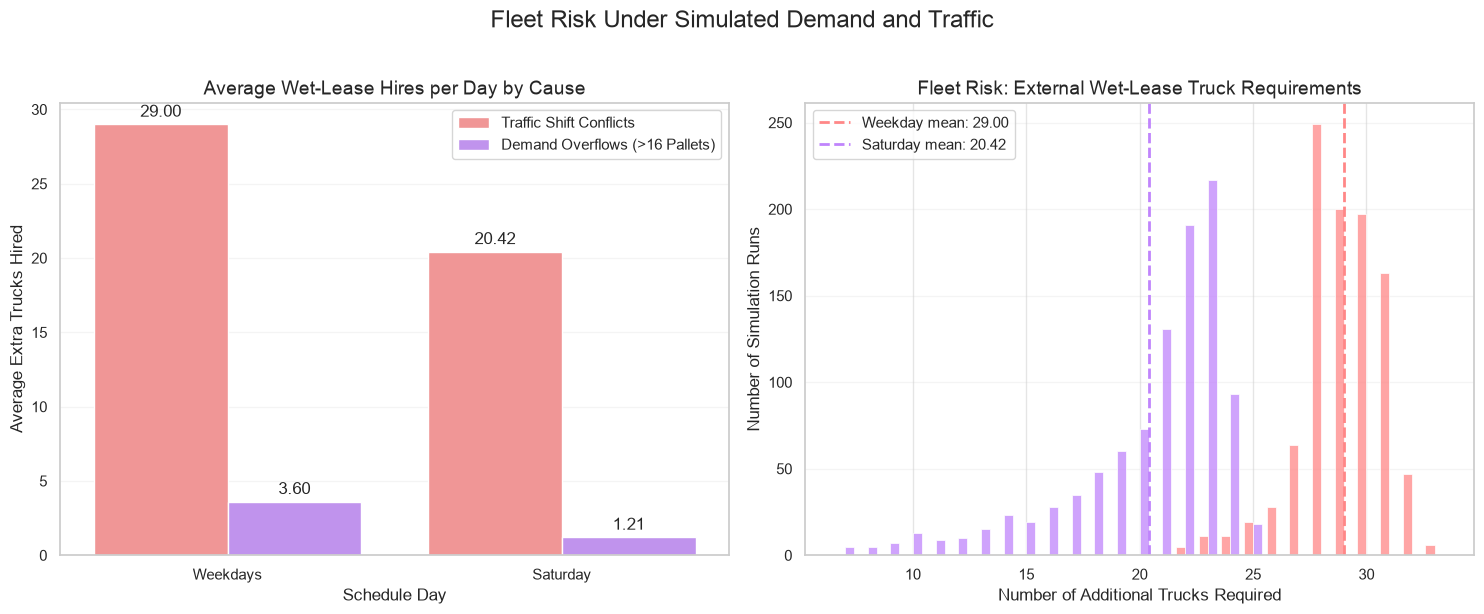

In [132]:
# ============================================================
# FLEET RISK — WET-LEASE HIRES + EXTRA TRUCK REQUIREMENTS
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 6)
)

ax1, ax2 = axes


# ============================================================
# LEFT — AVERAGE WET-LEASE HIRES BY CAUSE
# ============================================================

avg_hires = pd.DataFrame({
    "Schedule Day": [
        "Weekdays",
        "Weekdays",
        "Saturday",
        "Saturday"
    ],
    "Cause": [
        "Traffic Shift Conflicts",
        "Demand Overflows (>16 Pallets)",
        "Traffic Shift Conflicts",
        "Demand Overflows (>16 Pallets)"
    ],
    "Average Extra Trucks Hired": [
        results[
            "Weekday_Traffic_Conflict_Trucks"
        ].mean(),

        results[
            "Weekday_Demand_Overflow_Trucks"
        ].mean(),

        results[
            "Saturday_Traffic_Conflict_Trucks"
        ].mean(),

        results[
            "Saturday_Demand_Overflow_Trucks"
        ].mean()
    ]
})


sns.barplot(
    data=avg_hires,
    x="Schedule Day",
    y="Average Extra Trucks Hired",
    hue="Cause",
    palette=[
        COLOURS["traffic"],
        COLOURS["demand"]
    ],
    ax=ax1
)


ax1.set_title(
    "Average Wet-Lease Hires per Day by Cause",
    fontsize=14
)

ax1.set_xlabel(
    "Schedule Day"
)

ax1.set_ylabel(
    "Average Extra Trucks Hired"
)


for container in ax1.containers:

    ax1.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )


ax1.legend(
    title=""
)

ax1.grid(
    axis="y",
    alpha=0.2
)


# ============================================================
# RIGHT — FLEET RISK
# ============================================================

fleet_risk = pd.DataFrame({
    "Weekdays":
        results[
            "Weekday_Extra_Trucks_Required"
        ],

    "Saturday":
        results[
            "Saturday_Extra_Trucks_Required"
        ]
})


# Convert to long format
fleet_risk_long = fleet_risk.melt(
    var_name="Schedule Day",
    value_name="Extra Trucks Required"
)


sns.histplot(
    data=fleet_risk_long,
    x="Extra Trucks Required",
    hue="Schedule Day",
    discrete=True,
    multiple="dodge",
    shrink=0.8,
    palette=[
        COLOURS["traffic"],
        COLOURS["demand"]
    ],
    ax=ax2
)


weekday_mean = (
    fleet_risk["Weekdays"].mean()
)

saturday_mean = (
    fleet_risk["Saturday"].mean()
)


ax2.axvline(
    weekday_mean,
    color=COLOURS["traffic"],
    linestyle="--",
    linewidth=2,
    label=f"Weekday mean: {weekday_mean:.2f}"
)


ax2.axvline(
    saturday_mean,
    color=COLOURS["demand"],
    linestyle="--",
    linewidth=2,
    label=f"Saturday mean: {saturday_mean:.2f}"
)


ax2.set_title(
    "Fleet Risk: External Wet-Lease Truck Requirements",
    fontsize=14
)

ax2.set_xlabel(
    "Number of Additional Trucks Required"
)

ax2.set_ylabel(
    "Number of Simulation Runs"
)

ax2.legend()

ax2.grid(
    axis="y",
    alpha=0.2
)


# ============================================================
# OVERALL TITLE
# ============================================================

fig.suptitle(
    "Fleet Risk Under Simulated Demand and Traffic",
    fontsize=17,
    y=1.02
)


plt.tight_layout()
plt.show()